# Previsão de Falhas Estruturais Aplicadas no <span style="color:red;">Motor Brushless</span>

---

### Integrantes do grupo: 
- <span style="color:yellow;">Enrico Magalhães</span>;
-  Hugo Samuel;
- <span style="color:brown;">Vinícius Fernandes</span>;
- <span style="color:green;">Vitor Belo</span>.

---

### Parâmetros do grupo moto-propulsor utilizado: 
(Como contexto e limitação orçamentária desse estudo, destaca-se que nenhum componente foi adquirido para o projeto. Todos os materiais, e inclusive os ensaios, estavam disponíveis e foram realizados na oficina da equipe Trem Ki Voa Micro. O uso gratuito e facilitado desses componetes foi devido à todos os integrantes do grupo serem membros atuais ou ex-integrantes da equipe).

- *Motor:* Scorpion SII-4035-450;
- *Hélice:* Master Airscrew 16×10"× 3;
- *Baterias:* LiFePO4 e LIPO;
- *ESC:* ESCTurnigy® Plush-32 120A HV?????? SERÁ?;
- *Receptor:* FrSky® V8FR-II;
-*Regulador de tensão:* Castle Creations® CCBEC10A.

### Sensores:
- *Allegro® ACS712ELCTR*;
- *Célula de carga*;
- *Arduino UNO*;

---

### Repositório no Github: https://github.com/vitorvespoli/MachineLearning_Trabalho1

---

---


### Definição do problema

A SAE BRASIL é uma associação dedicada ao avanço da engenharia de mobilidade no país. Uma de suas principais iniciativas é o Projeto SAE BRASIL AeroDesign, um programa educacional que desafia estudantes universitários a conceber, projetar, construir e voar aeronaves rádio-controladas, simulando os mesmos desafios enfrentados pela indústria aeronáutica.

Na 26ª Competição SAE Brasil AeroDesign, uma falha no motor impediu o voo da equipe **Trem Ki Voa Micro** (equipe de competição da UFSJ) em uma de suas tentativas oficiais. O evento foi decisivo na pontuação final, resultando na obtenção do vice-campeonato nacional por uma margem de dois pontos em relação ao primeiro colocado.

A partir disso, surgiu a necessidade de desenvolver um modelo capaz de prever falhas com base nos dados de funcionamento do sistema, evitando que falhas passem despercebidas antes de um voo oficial. Dentre as inúmeras falhas que podem interferir no sistema, para a realização desse trabalho, foram escolhidas 3 falhas principais:

- Desbalanceamento de hélice;
- Hélice quebrada;
- Rotação invertida do motor.

<div align="center">
<img src="pics\teste.png" width="1000">
</div>

## Imports:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import statistics as st

### Função para plotar os gráficos

In [3]:
def plot_technical(
    x,
    y,
    title="Título do Gráfico",
    xlabel="Eixo X",
    ylabel="Eixo Y",
    labels=None,
    linewidth=2.0,
    markers=None,
    figsize=(8, 5),
    grid=True,
    save=False,
    filename="grafico.png",
    dpi=300
):
    plt.figure(figsize=figsize)

    # Detecta se y é curva única ou lista de curvas
    if isinstance(y, (pd.Series, np.ndarray, list, tuple)):
        if len(y) > 0 and not isinstance(y[0] if isinstance(y, (list, tuple, np.ndarray)) else y.iloc[0], (list, tuple, np.ndarray, pd.Series)):
            y = [y]
    else:
        y = [y]

    n_curves = len(y)

    if labels is None:
        labels = [f"Curva {i+1}" for i in range(n_curves)]

    if markers is None:
        markers = [None] * n_curves

    for i in range(n_curves):
        plt.plot(
            x,
            y[i],
            label=labels[i],
            linewidth=linewidth,
            marker=markers[i]
        )

    plt.title(title, fontsize=13)
    plt.xlabel(xlabel, fontsize=11)
    plt.ylabel(ylabel, fontsize=11)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    if grid:
        plt.grid(True, linestyle='--', alpha=0.7)

    if labels is not None:
        plt.legend(fontsize=10)

    plt.tight_layout()

    if save:
        plt.savefig(filename, dpi=dpi, bbox_inches='tight')

    plt.show()

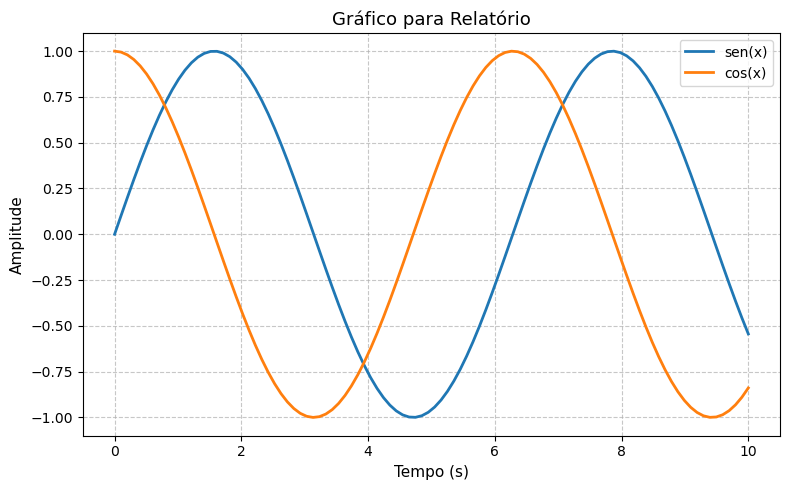

In [ ]:
import numpy as np

x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

plot_technical(
    x,
    [y1, y2],
    title="Plot Cos e Sen",
    xlabel="Tempo (s)",
    ylabel="Amplitude",
    labels=["sen(x)", "cos(x)"],
    save=True,
    filename="grafico_1.png"
)

A seção abaixo foi criada para o armazenamento dos diretórios em que os dados coletados se encontram. Estes são armazenados em um dicionário, sendo possível acessar o diretório de cada operação a partir das chaves definidas ("normal", "desbalanceada", "quebrada", "invertida").

In [ ]:
# Pasta atual
thisFolder = os.getcwd()
dataFolder = os.path.join(thisFolder, "dados_coletados")

# Seleciona as pastas de cada operação
desbalanceadaFolder = os.path.join(dataFolder, "helice_desbalanceada")
quebradaFolder = os.path.join(dataFolder, "helice_quebrada")
normalFolder = os.path.join(dataFolder, "normal")
invertidaFolder = os.path.join(dataFolder, "rotacao_invertida")

folders = {
    "normal": normalFolder,
    "desbalanceada": desbalanceadaFolder,
    "quebrada": quebradaFolder,
    "invertida": invertidaFolder
    
}

## Análise Exploratória de Dados
Após a coleta e tratamento dos dados, esses foram segmentados em duas seções de transitórios (transitório inicial e final) e uma seção de regime estacionário, em que o manche do motor permanece no limite máximo, corroborando no máximo consumo de potência disponível conforme as capacidades do sistema.

A função abaixo realiza a identificação dessas seções. Primeiramente, há a aquisição da média referente aos valores entre 25% e 75% dos dados (seção aproximada de regime permanente), após isso, o algoritmo realiza uma varredura nas linhas dos dados de corrente em Ampères, sendo um dos principais parâmetros direcionados ao comportamento do sistema. A varredura ocorre visando encontrar os pontos de chaveamento de seções. O chaveamento entre o transitório inicial e o regime permanente é quando há o encontro de um dado entre 90 e 130% da média obtida. Já o chaveamento entre o regime permanente e o transitório final ocorre quando há o encontro de um dado abaixo de 82% do valor da média obtida. A busca pelo ponto de chaveamento entre o regime permanente e transitório final ocorre somente se o primeiro ponto de chaveamento já estiver obtido. Os valores de chaveamento foram obtidos a partir de testes.

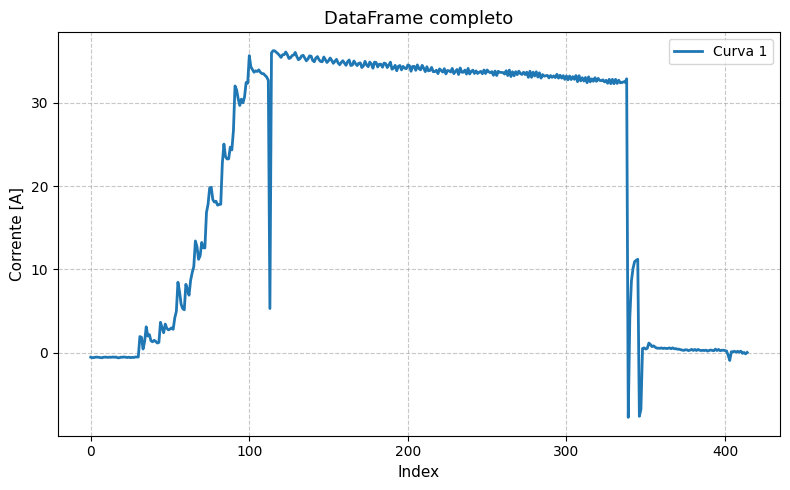

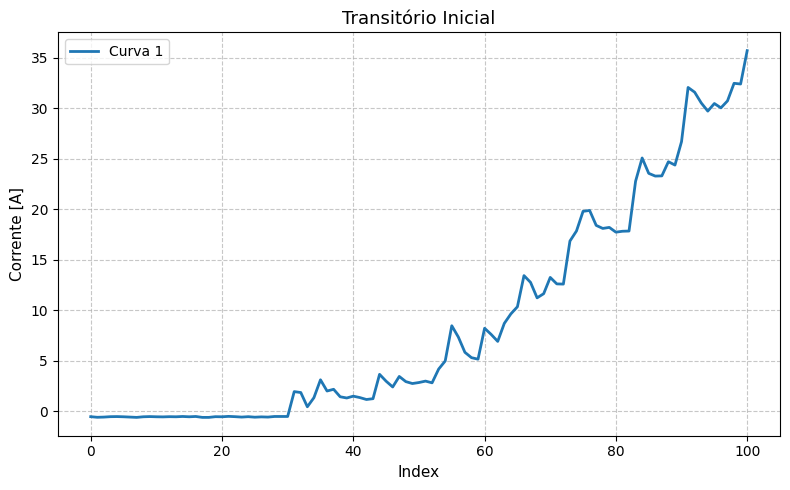

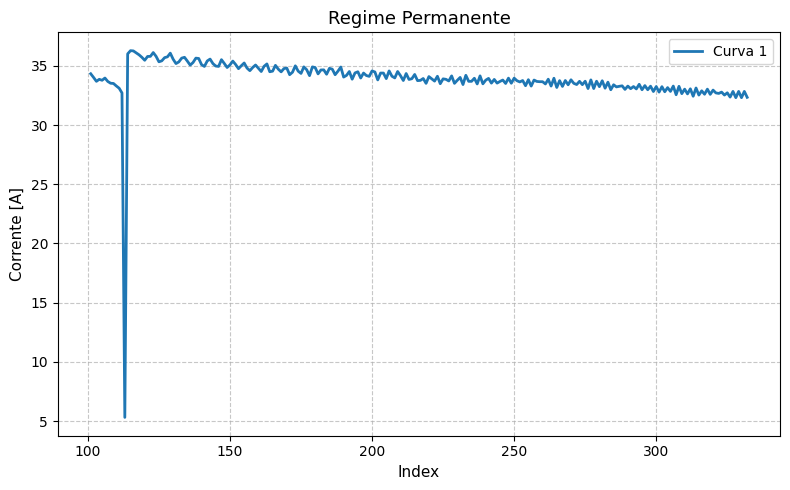

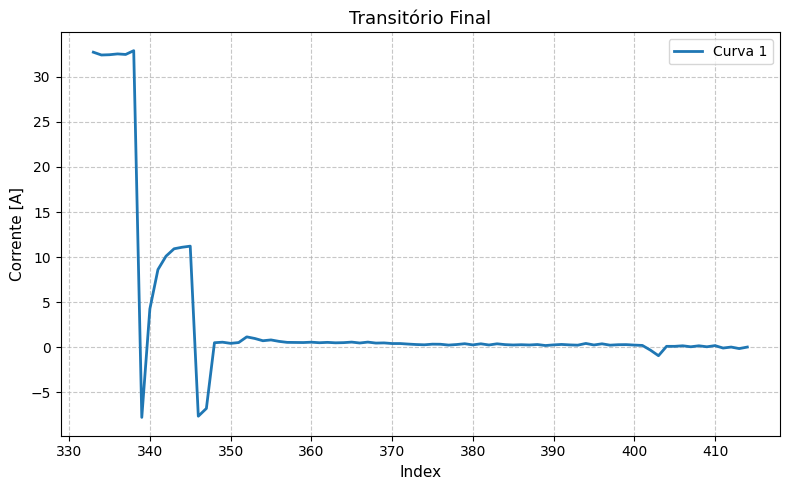

In [92]:
def transitory_stacionary(df):
    
    loc_i = df.columns.get_loc("Corrente_A") + 1

    q1 = df["Corrente_A"].quantile(0.30)
    q3 = df["Corrente_A"].quantile(0.70)

    df_50 = df[(df["Corrente_A"] >= q1) & (df["Corrente_A"] <= q3)]

    flag_stac = False
    transitory_2 = None
    flag_transitory_1 = True

    mean = df_50["Corrente_A"].mean()
    

    for idx, row in enumerate(df.itertuples()):
        if ((np.abs(row[loc_i]) >= 0.99*mean) & (np.abs(row[loc_i]) <= 1.3*mean) & flag_transitory_1):
            transitory_1 = idx + 10
            flag_stac = True
            flag_transitory_1 = False
            
        if flag_stac:
            if ((np.abs(row[loc_i]) <= 0.82*mean) & (np.abs(row[loc_i]) >= 0.3*mean)):
                transitory_2 = idx - 8
                break

    df_0 = df.iloc[:transitory_1]
    if transitory_2 != None:
        df_1 = df.iloc[transitory_1:transitory_2]
        df_2 = df.iloc[transitory_2:]
    else:
        df_1 = df.iloc[transitory_1:]
        df_2 = None

    return df_0, df_1, df_2

df_ex = pd.read_excel(os.path.join(quebradaFolder, "helice_quebrada_4.xlsx"))
df0, df1, df2 = transitory_stacionary(df_ex)

plot_technical(df_ex.index, df_ex["Corrente_A"], title="DataFrame completo", xlabel="Index", ylabel="Corrente [A]")
plot_technical(df0.index, df0["Corrente_A"], title="Transitório Inicial", xlabel="Index", ylabel="Corrente [A]")
plot_technical(df1.index, df1["Corrente_A"], title="Regime Permanente", xlabel="Index", ylabel="Corrente [A]")
plot_technical(df2.index, df2["Corrente_A"], title="Transitório Final", xlabel="Index", ylabel="Corrente [A]")

Os parâmetros considerados relevantes para a análise do sistema foram organizados por meio da classe statisticsParams, definida na célula abaixo. O objetivo é que cada objeto seja um tipo de operação, armazenando informações da média, mediana, valor máximo, valor mínimo, desvio padrão, skewness e kurtosis para cada coluna presente na operação. Além desses valores, é possível obter também a quantidade de dados para os transitórios e regime permanente.

In [75]:
class statisticsParams:
    def __init__(self, name = None, df = None, tr1_qty = None, regime_qty = None, tr2_qty = None):
        
        mean = {}
        median = {}
        max = {}
        min = {}
        desv_padr = {}
        skew = {}
        kurtosis = {}
        mode = {}

        if df is not None:
            header = df.columns.to_list()    

            for h in header:
                mean[h] = df[h].mean()
                median[h] = df[h].median()
                max[h] = df[h].max()
                min[h] = df[h].min()
                desv_padr[h] = st.stdev(df[h])
                skew[h] = df[h].skew()
                kurtosis[h] = df[h].kurtosis()
                mode[h] = st.mode(df[h])

            self.name = name
            self.header = header
            self.mean = mean
            self.median = median
            self.max = max
            self.min = min
            self.desv_padr = desv_padr
            self.skew = skew
            self.kurtosis = kurtosis
            self.mode = mode

            self.tr1_qty = tr1_qty
            self.regime_qty = regime_qty
            self.tr2_qty = tr2_qty

        else:
            self.name = ""
            self.mean = mean
            self.median = median
            self.max = max
            self.min = min
            self.desv_padr = desv_padr
            self.skew = skew
            self.kurtosis = kurtosis
            self.mode = mode

            self.tr1_qty = 0
            self.regime_qty = 0
            self.tr2_qty = 0

A função abaixo é realizada com o objetivo de agrupar todas as coletas de dados realizadas em um tipo de operação, armazenando-as em um objeto "total", com as informações médias dos parâmetros estatísticos avaliados anteriormente.

In [76]:
def statisticsGroup(ops, name):
    header = ops[0].header
    
    stat_temp = statisticsParams()
    

    for h in header:
        tr1_qty = 0
        tr2_qty = 0
        regime_qty = 0

        mean = []
        median = []
        maximum = []
        minimum = []
        desv_padrao = []
        skew = []
        kurtosis = []
        mode = []

        for op in ops:
            tr1_qty += op.tr1_qty
            tr2_qty += op.tr2_qty
            regime_qty += op.regime_qty

            mean.append(op.mean[h])
            median.append(op.median[h])
            maximum.append(op.max[h])
            minimum.append(op.min[h])
            desv_padrao.append(op.desv_padr[h])
            skew.append(op.skew[h])
            kurtosis.append(op.kurtosis[h])
            mode.append(op.mode[h])

        stat_temp.mean[h] = st.mean(mean)
        stat_temp.median[h] = st.mean(median)
        stat_temp.max[h] = max(maximum)
        stat_temp.min[h] = min(minimum)
        stat_temp.desv_padr[h] = st.mean(desv_padrao)
        stat_temp.skew[h] = st.mean(skew)
        stat_temp.kurtosis[h] = st.mean(kurtosis)
        stat_temp.mode[h] = st.mean(mode)
    
    stat_temp.name = name
    stat_temp.header = header
    stat_temp.tr1_qty = tr1_qty
    stat_temp.tr2_qty = tr2_qty
    stat_temp.regime_qty = regime_qty

    return stat_temp

Com o objetivo de visualizar as informações relevantes, a função abaixo foi definida, cujo argumento é um objeto da classe statisticParams, definida anteriormente. A função irá imprimir no terminal os valores armazenados no objeto.

In [77]:
def stats_dataFrame(class_param):
    
    resumo = pd.DataFrame({
            "parameter": (h for h in class_param.header),
            "media": (class_param.mean[h] for h in class_param.header),
            "median": (class_param.median[h] for h in class_param.header),
            "mode": (class_param.mode[h] for h in class_param.header),
            "maximum": (class_param.max[h] for h in class_param.header),
            "minimum": (class_param.min[h] for h in class_param.header),
            "desvio_padrao": (class_param.desv_padr[h] for h in class_param.header),
            "skewness": (class_param.skew[h] for h in class_param.header),
            "kurtosis": (class_param.kurtosis[h] for h in class_param.header)
        })
    
    print("transitorio 1, quantidade de dados = ", class_param.tr1_qty)
    print("regime, quantidade de dados = ", class_param.regime_qty)
    print("transitorio 2, quantidade de dados = ", class_param.tr2_qty)
    print(resumo)

In [78]:
def concatDataframes(df_list):
    for i, df in enumerate(df_list):
        if i != 0:
            df_tot = pd.concat([df_tot, df], ignore_index=True)
        else:
            df_tot = df
    
    return df_tot

Como foram realizadas múltiplas aquisições para cada tipo de operação, com exceção dos máximos e mínimos, o restante dos parâmetros abaixo são apresentados como a média entre as aquisições de cada operação. 

Abaixo contém um resumo com parâmetros relevantes para a análise desejada, como a quantidade total de pontos em cada intervalo de operação após o ajuste dos dados.


============= normal =============
transitorio 1, quantidade de dados =  371
regime, quantidade de dados =  1249
transitorio 2, quantidade de dados =  274
     parameter        media       median         mode    maximum    minimum  \
0  Celula1_Kgf  -672.082055  -697.666667  -701.666667  -588.0000  -858.0000   
1  Celula2_Kgf  2586.688066  2599.000000  2654.333333  3047.0000  1896.0000   
2     Tensao_V    13.447010    13.473333    13.530000    14.2500    12.5300   
3   Corrente_A    31.328585    31.690000    32.393333    38.1600    24.4600   
4   Potencia_W   422.109796   427.799667   447.310533   523.1736   327.5194   

   desvio_padrao  skewness  kurtosis  
0      47.768687 -0.318969 -0.731504  
1     164.362891 -0.757454  3.800518  
2       0.216853  0.362338  0.702879  
3       1.517163 -0.369482 -0.069664  
4      24.033304 -0.385402 -0.372046  


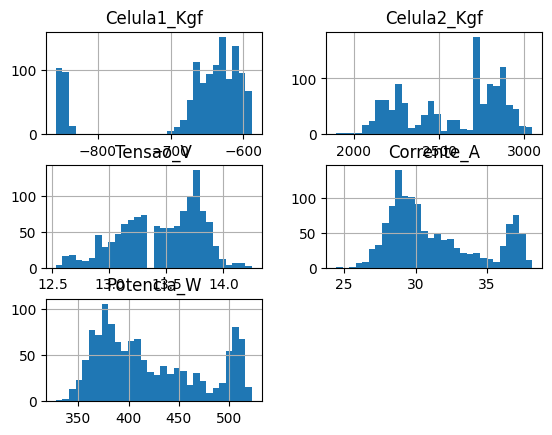


============= desbalanceada =============
transitorio 1, quantidade de dados =  503
regime, quantidade de dados =  1196
transitorio 2, quantidade de dados =  357
     parameter        media       median         mode    maximum    minimum  \
0  Celula1_Kgf  -873.849231  -896.000000  -891.000000  -526.0000 -1125.0000   
1  Celula2_Kgf  3009.642789  2993.500000  2989.666667  3957.0000  2253.0000   
2     Tensao_V    13.006000    12.993333    13.046667    13.9200    12.3100   
3   Corrente_A    37.963949    37.968333    37.686667    48.2200    28.2900   
4   Potencia_W   495.583061   494.778283   507.963600   671.2224   354.4737   

   desvio_padrao  skewness  kurtosis  
0     150.435346  0.633173 -0.176183  
1      94.889994  0.544355  1.005147  
2       0.168784  0.954582  1.759211  
3       1.165663 -1.171685  9.037183  
4      20.408923 -0.365089  4.521960  


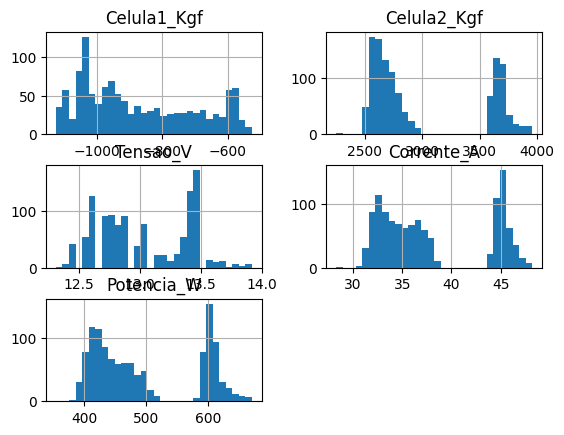


============= quebrada =============
transitorio 1, quantidade de dados =  565
regime, quantidade de dados =  1929
transitorio 2, quantidade de dados =  561
     parameter        media      median        mode    maximum    minimum  \
0  Celula1_Kgf  -558.939791  -547.00000  -553.00000  -398.0000 -1872.0000   
1  Celula2_Kgf  2437.788871  2440.40000  2402.80000  2799.0000  -793.0000   
2     Tensao_V    13.308742    13.27800    13.24800    14.2500    12.3100   
3   Corrente_A    33.487286    33.32300    33.16200    41.2200     5.3100   
4   Potencia_W   445.891256   442.17216   446.63924   584.9118    69.3486   

   desvio_padrao  skewness   kurtosis  
0      60.992222 -1.631127   5.249332  
1     156.673420 -0.119933   5.264938  
2       0.179210  0.885240   1.414667  
3       1.303160 -1.797598  30.043291  
4      21.902336 -0.990214  19.654064  


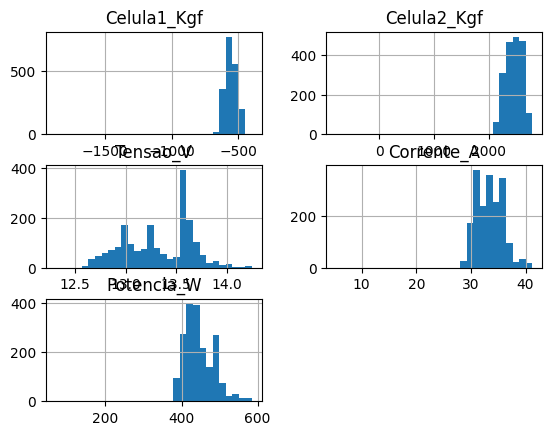


============= invertida =============
transitorio 1, quantidade de dados =  213
regime, quantidade de dados =  820
transitorio 2, quantidade de dados =  160
     parameter        media      median       mode   maximum   minimum  \
0  Celula1_Kgf   770.892018   768.50000   752.5000   851.000   716.000   
1  Celula2_Kgf -1691.418767 -1683.00000 -1685.5000 -1473.000 -1932.000   
2     Tensao_V    13.406200    13.41500    13.4450    14.250    12.690   
3   Corrente_A    38.800534    38.80500    38.5250    43.200    35.400   
4   Potencia_W   520.600880   520.95895   513.2275   613.008   449.226   

   desvio_padrao  skewness  kurtosis  
0      26.059539  0.874784  0.630372  
1      69.007919 -0.671848  0.526064  
2       0.180887  0.904310  1.864118  
3       1.254211  0.258417 -0.409458  
4      23.554031  0.435794 -0.078874  


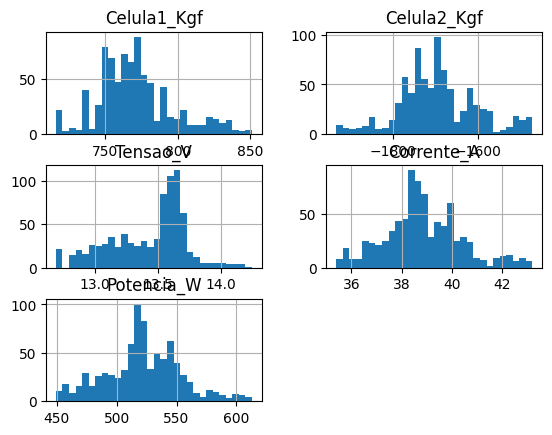

In [94]:
for fold in folders:
    df1s = []

    op_1s = []
    op_0s = []
    op_2s = []
    
    regime_qty = 0
    tr1_qty = 0
    tr2_qty = 0

    print("")
    print("=============", fold, "=============")

    files_temp = [os.path.join(folders[fold], x) for x in os.listdir(folders[fold]) if x.endswith(".xlsx")]

    # Cria uma lista com todos os DataFrames contidos na pasta atual
    dfs = [pd.read_excel(f) for f in files_temp]

    # Acessa cada DataFrame da lista de DataFrames da pasta atual
    for i, df_i in enumerate(dfs):

        df_i = df_i.drop(columns="Celula3_Kgf")
        df_i = df_i.drop(columns="Tempo")
        df_i = df_i.drop(columns="RPM")
       
        df_0, df_1, df_2 = transitory_stacionary(df_i)

        tr1_qty = len(df_0)
        regime_qty = len(df_1)
        tr2_qty = len(df_2)

        df1s.append(df_1)

        
        op_1 = statisticsParams((fold)+f"_{i}", df_1, tr1_qty, regime_qty, tr2_qty)
        op_1s.append(op_1)

    op_1_total = statisticsGroup(op_1s, fold)
    stats_dataFrame(op_1_total)

    df1_tot = concatDataframes(df1s)
    df1_tot.hist(bins = 30)
    #df1s[0].hist(bins = 30)
    #df1_tot.plot()

    plt.show()

Observa-se que, dentre todas as operações, o ensaio com a hélice desbalanceada retornou um valor maior de tração (Celula1_Kgf), em média, do que as outras operações, visto que, de acordo com a montagem dos componentes na bancada, sinal negativo indica tração, para a célula de carga 1. A hélice selecionada para realizar esse ensaio pode ter apresentado melhores características aerodinâmicas do que as outras, apesar de serem do mesmo modelo. Apesar disso, nota-se uma maior dispersão dos valores conforme indicado pelo desvio padrão, o que é esperado, devido à assimetria de inércia no plano perpendicular ao diâmetro da hélice. Ademais, para esse mesmo caso, é possível observar uma carga de torque (Celula2_Kgf) mais elevada quando comparado com as outras operações.

Com exceção da operação de hélice desbalanceada, a operação normal apresentou maior valor de tração, o que era esperado, visto que a operação com hélice quebrada deve apresentar queda de eficiência (devido à perda parcial de uma das pás) e a operação de rotação invertida deve indicar inversão do sinal, como é possível ver na disposição dos valores acima.

Nota-se que, para a operação normal, com exceção dos valores de torque, há a tendência de se obter uma curva semelhante a normal, a partir dos valores de skewness (assimetria) e kurtosis (curtose), que se aproximam de zero, em geral, o que indica a tendência de uma curva mesocúrtica e simétrica. É importante ressaltar que, o valor de kurtosis indicado é, na verdade, excesso de curtose.

Para a operação de hélice desbalanceada, evidencia-se uma assimetria nos valores de torque, corrente, tensão e potência, além dos altos valores de curtose sobre os mesmos parâmetros, apresentando a tendência de uma curva assimétrica a leptocúrtica.

Percebe-se que, para a operação de hélice quebrada, apesar da menor assimetria quando comparada ao caso anterior, ainda apresenta altos valores de excesso de curtose. Diferente dos casos anteriores, para esse tipo de operação percebe-se relativa assimetria e alta curtose nos valores de tração, também.

Já para a operação de rotação invertida, pode-se concluir que houve um elevado valor de curtose para a tração.